<a href="https://colab.research.google.com/github/Qurat-17/MINIST_Classification/blob/main/mnist_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [3]:

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display the shapes of the loaded data to verify
print(f"Shape of training images: {x_train.shape}")
print(f"Shape of training labels: {y_train.shape}")
print(f"Shape of test images: {x_test.shape}")
print(f"Shape of test labels: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of training images: (60000, 28, 28)
Shape of training labels: (60000,)
Shape of test images: (10000, 28, 28)
Shape of test labels: (10000,)


In [6]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

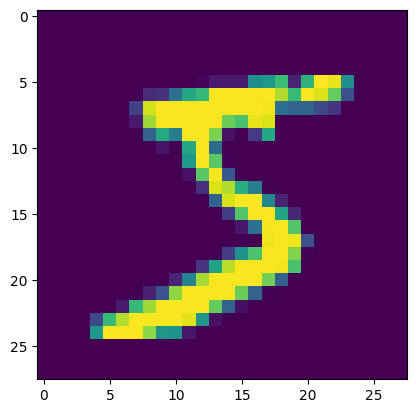

In [13]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.show()

In [42]:
x_train=x_train/255
x_test=x_test/255



In [16]:
#x_train[0]

In [19]:
model=Sequential()
model.add(Flatten(input_shape=(28,28))) #will convert theh higher dimesional array into 1D in our case wa have (28,28 image )
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
#why this loss fundtion because we need not to convert the labels(0,9)in output into one hot encoding


In [23]:
history = model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9156 - loss: 0.2919 - val_accuracy: 0.9528 - val_loss: 0.1661
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9629 - loss: 0.1237 - val_accuracy: 0.9623 - val_loss: 0.1219
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9744 - loss: 0.0849 - val_accuracy: 0.9646 - val_loss: 0.1130
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9804 - loss: 0.0640 - val_accuracy: 0.9706 - val_loss: 0.1016
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9846 - loss: 0.0497 - val_accuracy: 0.9737 - val_loss: 0.0956
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9877 - loss: 0.0388 - val_accuracy: 0.9728 - val_loss: 0.0970
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9908 - loss: 0.0292 - val_accuracy: 0.9727 - val_loss: 0.1019
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9912 - loss: 0.0273 

In [27]:
y_prob=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [29]:
y_pred = y_prob.argmax(axis=1)

In [30]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9724

In [34]:
history.history

{'accuracy': [0.9155833125114441,
  0.9628750085830688,
  0.9743958115577698,
  0.9804166555404663,
  0.98458331823349,
  0.9877499938011169,
  0.9907916784286499,
  0.9912083148956299,
  0.9927916526794434,
  0.9941250085830688],
 'loss': [0.2918757200241089,
  0.12367897480726242,
  0.08487454056739807,
  0.06395182013511658,
  0.04966979846358299,
  0.03883574903011322,
  0.029215415939688683,
  0.027324078604578972,
  0.02176537550985813,
  0.018408041447401047],
 'val_accuracy': [0.952833354473114,
  0.9623333215713501,
  0.9645833373069763,
  0.9705833196640015,
  0.9736666679382324,
  0.9727500081062317,
  0.9726666808128357,
  0.9755833148956299,
  0.9735000133514404,
  0.9710000157356262],
 'val_loss': [0.16608944535255432,
  0.12187918275594711,
  0.11295028030872345,
  0.10156325250864029,
  0.09564348310232162,
  0.09704268723726273,
  0.10192742198705673,
  0.09529487043619156,
  0.11540266126394272,
  0.12098819762468338]}

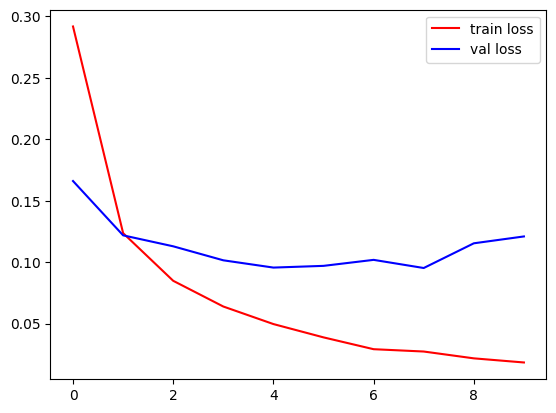

In [35]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train loss')
plt.plot(history.history['val_loss'],color='blue',label='val loss')
plt.legend()
plt.show()

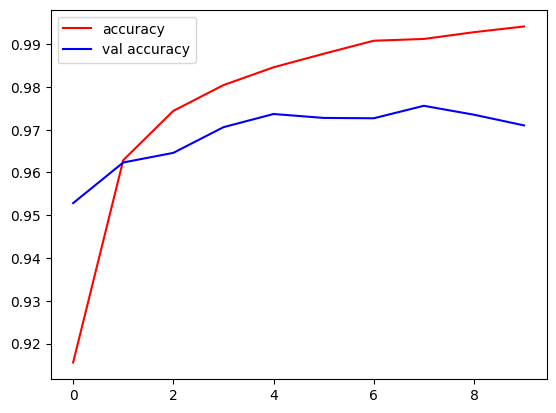

In [36]:
plt.plot(history.history['accuracy'],color='red',label='accuracy')
plt.plot(history.history['val_accuracy'],color='blue',label='val accuracy')
plt.legend()
plt.show()

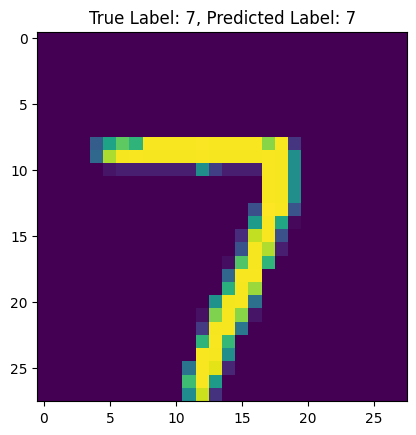

For sample 3400, the true label and predicted label are the same: 7


In [45]:
# we can change the 'sample_idx' to view different test images
sample_idx =3400

# Display the test image
plt.imshow(x_test[sample_idx])

# Display the true and predicted labels
plt.title(f"True Label: {y_test[sample_idx]}, Predicted Label: {y_pred[sample_idx]}")
plt.show()

# Programmatic check for comparison
if y_test[sample_idx] == y_pred[sample_idx]:
    print(f"For sample {sample_idx}, the true label and predicted label are the same: {y_test[sample_idx]}")
else:
    print(f"For sample {sample_idx}, the true label ({y_test[sample_idx]}) and predicted label ({y_pred[sample_idx]}) are different.")